# Статистический анализ данных сервиса аренды самокатов GoFast

_**Описание проекта**_

Основная цель проекта: проанализировать данные сервиса аренды самокатов GoFast и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением.

Сервисом можно пользоваться:
1. без подписки:
 * абонентская плата отсутствует;
 * стоимость одной минуты поездки — 8 рублей;
 * стоимость старта (начала поездки) — 50 рублей;
2. с подпиской Ultra:
 * абонентская плата — 199 рублей в месяц;
 * стоимость одной минуты поездки — 6 рублей;
 * стоимость старта — бесплатно.

**Описание исходных данных**

В исходных данных есть информация о пользователях, их поездках и подписках.

_1. Пользователи — *'users_go.csv'*:_
 * 'user_id' - уникальный идентификатор пользователя;
 * 'name' - имя пользователя;
 * 'age' - возраст;
 * 'city' - город;
 * 'subscription_type' - тип подписки (free, ultra). 

_2. Поездки — *'rides_go.csv'*:_
 * user_id' - уникальный идентификатор пользователя;
 * 'distance' - расстояние, которое пользователь проехал в текущей сессии (в метрах);
 * 'duration' - продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»;
 * 'date' - дата совершения поездки.

_3. Подписки — *'subscriptions_go.csv'*:_
 * 'subscription_type' - тип подписки;
 * 'minute_price' - стоимость одной минуты поездки по данной подписке;
 * 'start_ride_price' - стоимость начала поездки;
 * 'subscription_fee' - стоимость ежемесячного платёж. 

_**Импорт библиотек**_

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
from scipy.stats import binom

#### Шаг 1. Загрузка данных

In [2]:
users_go = pd.read_csv('/datasets/users_go.csv')

rides_go = pd.read_csv('/datasets/rides_go.csv')

subscriptions_go = pd.read_csv('/datasets/subscriptions_go.csv')


In [3]:
display('Таблица users_go:', users_go.head())

display('Таблица rides_go:', rides_go.head())

display('Таблица subscriptions_go:', subscriptions_go)

'Таблица users_go:'

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


'Таблица rides_go:'

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


'Таблица subscriptions_go:'

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


_**Общая информация:**_

In [4]:
print(users_go.info())
print('Количество явных дубликатов в `users_go.csv` = ', users_go.duplicated().sum())
print(rides_go.info())
print('Количество явных дубликатов в `rides_go.csv` = ', rides_go.duplicated().sum())
print(subscriptions_go.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
None
Количество явных дубликатов в `users_go.csv` =  31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
None
Количество явных дубликатов в `rides_go.csv` = 

_**датафрейм 'users_go'**_

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 458.7 KB
None

           user_id          age
count  1565.000000  1565.000000
mean    762.633866    24.922045
std     443.260155     4.553496
min       1.000000    12.000000
25%     378.000000    22.000000
50%     762.000000    25.000000
75%    1146.000000    28.000000
max    1534.000000    43.000000


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


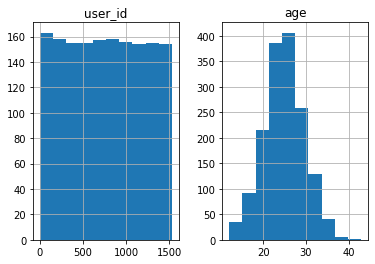

In [5]:
 print(users_go.info(memory_usage='deep')) 
print()
print(users_go.describe())
users_go.hist()
users_go.head()

В ‘users_go’ 5 столбцов и 1565 строк без пропусков и выбросов. В столбцах ‘user_id’, ‘age’, ‘subscription_type’ необходимо изменить тип данных. Есть дубликаты в столбце ‘user_id’.

In [6]:
print(len(users_go['user_id'].unique()), 'уникальных значений из', users_go['user_id'].count(), 'строк')
print('От', users_go['user_id'].min(), 'до', users_go['user_id'].max())

1534 уникальных значений из 1565 строк
От 1 до 1534


_**Возраст:**_

In [7]:
print(len(users_go['age'].unique()), 'уникальных значений из', users_go['age'].count(), 'строк')
print('От', users_go['age'].min(), 'до', users_go['age'].max())

29 уникальных значений из 1565 строк
От 12 до 43


_**Названия населенных пунктов**_

In [8]:
users_go['city'].unique()

array(['Тюмень', 'Омск', 'Москва', 'Ростов-на-Дону', 'Краснодар',
       'Пятигорск', 'Екатеринбург', 'Сочи'], dtype=object)

_**Датафрейм 'rides_go'**_

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
None

            user_id      distance      duration
count  18068.000000  18068.000000  18068.000000
mean     842.869936   3070.659976     17.805011
std      434.734317   1116.831209      6.091051
min        1.000000      0.855683      0.500000
25%      487.000000   2543.226360     13.597563
50%      889.000000   3133.609994     17.678395
75%     1213.250000   3776.222735     21.724800
max     1534.000000   7211.007745     40.823963


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


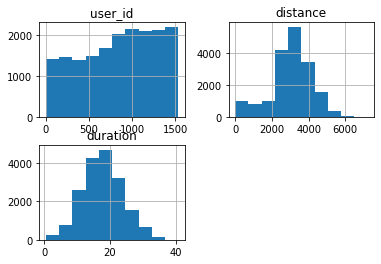

In [9]:
print(rides_go.info())
print()
print(rides_go.describe())
rides_go.hist() 
rides_go.head()

В ‘rides_go’ 4 столбца и 18068 строк без пропусков и выбросов. Типы столбцов ‘user_id’ и ‘date’ нужно изменить. Возможны выбросы в столбцах ‘distance’ и ‘duration’.

_**Датафрейм 'subscriptions_go'**_

In [10]:
print(subscriptions_go.info())
subscriptions_go.head() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes
None


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


4 столбца и 2 строки без пропусков и выбросов. Тип данных в столбце ‘subscription_type’ нужно будет изменить.

#### Шаг 2. Предобработка данных

In [11]:
#предобработка 'users_go'
#округлим значения до 2 запятых
rides_go['distance'] = rides_go['distance'].round(2)

In [12]:
#изменим тип данных 'duration'
rides_go['duration'] = np.ceil(rides_go['duration']).astype('int')

In [13]:
#корректировка столбца 'date'
rides_go['date'] = pd.to_datetime(rides_go['date'], format='%Y-%m-%d')

In [14]:
#добавление столбца 'month' с номером месяца в 'rides_go'
rides_go['month'] = pd.DatetimeIndex(rides_go['date']).month

In [15]:
#добавление столбца 'year' с номером месяца в 'rides_go'
rides_go['year'] = pd.DatetimeIndex(rides_go['date']).year

In [16]:
rides_go['year'].unique()

array([2021])

In [17]:
#обработка дубликатов в столбце 'user_id' в 'users_go'
users_go = users_go.sort_values(by='user_id').loc[users_go['user_id'].duplicated() == False]

In [18]:
#проверка на дубликаты в 'users_go'
users_go.sort_values(by='user_id').loc[users_go['user_id'].duplicated() == True].count()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [19]:
#проверка результатов обработки
users_go.info()
users_go.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1534 entries, 0 to 1533
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1534 non-null   int64 
 1   name               1534 non-null   object
 2   age                1534 non-null   int64 
 3   city               1534 non-null   object
 4   subscription_type  1534 non-null   object
dtypes: int64(2), object(3)
memory usage: 71.9+ KB


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  int64         
 3   date      18068 non-null  datetime64[ns]
 4   month     18068 non-null  int64         
 5   year      18068 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 847.1 KB
None

   user_id  distance  duration       date  month  year
0        1   4409.92        26 2021-01-01      1  2021
1        1   2617.59        16 2021-01-18      1  2021
2        1    754.16         7 2021-04-20      4  2021
3        1   2694.78        19 2021-08-11      8  2021
4        1   4028.69        27 2021-08-28      8  2021

            user_id      distance      duration         month     year
count  18068.000000  18068.000000  18068.0000

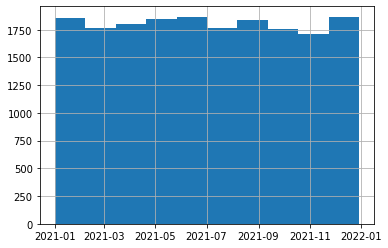

In [20]:
#rides_go'
print(rides_go.info())
print()
print(rides_go.head())
print()
print(rides_go.describe())
print()
print('Анализ дат:')
print('Минимальная дата:', rides_go['date'].min())
print('Максимальная дата:', rides_go['date'].max())
rides_go['date'].hist()
plt.show()

*В ‘rides_go’ был добавлен столбец ‘month’ и изменены типы этих столбцов. Диапазон дат с 01.01.2021 по 30.12.2021. В пределах этого диапазона дат количество значений распределено относительно равномерно.*

In [21]:
#инфо по 'subscriptions_go'
subscriptions_go.info()
subscriptions_go.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


# Вывод:

* В данных users_go округлили distance в метрах до 2 знаков после запятой; 
* Округлили duration, перевели в int; 
* Столбец date приведен к типу datetime64; 
* Создан столбец month с номером месяца из date; 
* В данных subscriptions_go изменений не было.

#### Шаг 3. Исследовательский анализ данных

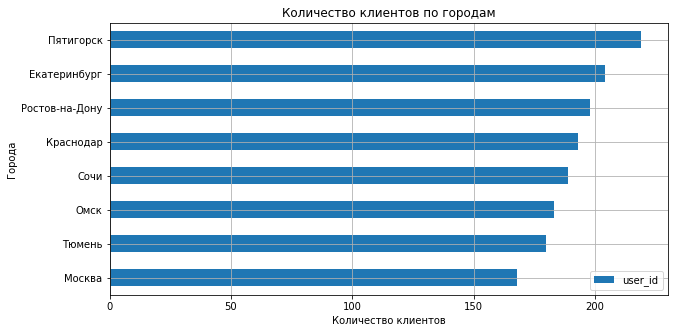

Количество клиентов по городам 


,user_id
city,
Пятигорск,219
Екатеринбург,204
Ростов-на-Дону,198
Краснодар,193
Сочи,189
Омск,183
Тюмень,180
Москва,168


In [22]:
#насколько много и часто попадаются города в выборке
(
    users_go.pivot_table(index='city', values='user_id', aggfunc='count').sort_values(by='user_id', ascending=True)
    .plot(kind='barh', grid=True, figsize=(10, 5))
)
plt.title('Количество клиентов по городам')
plt.ylabel('Города')
plt.xlabel('Количество клиентов')

plt.show()
print('Количество клиентов по городам ') 
users_go.pivot_table(index='city', values='user_id', aggfunc='count').sort_values(by='user_id', ascending=False)

По графику видно, что первый город Пятигорск, второй Екатеринбург, затем Ростов-на-Дону. В первой половине располагаются в основном южные города, где сезон проката продолжительнее, исключение - Екатеринбург на 2 позиции.

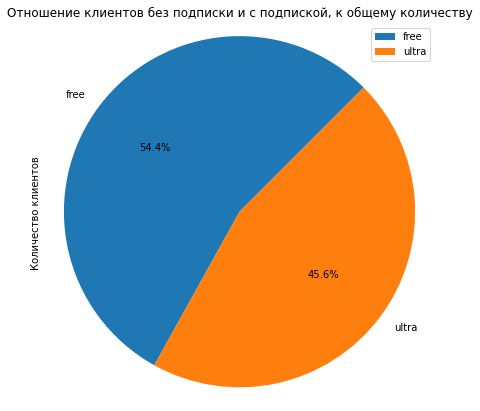

In [23]:
#соотношение клиентов с подпиской ultra и без подписки free
(
    users_go.pivot_table(index='subscription_type', values='user_id', aggfunc='count')
    .plot.pie(y='user_id', figsize=(7,7),  label='Количество клиентов', 
    autopct='%1.1f%%', startangle=45,
    title='Отношение клиентов без подписки и с подпиской, к общему количеству')

)
plt.axis('equal')
plt.show()

*Количество клиентов без подписки free 54,4% выше клиентов с подпиской ultra 45,6%.*

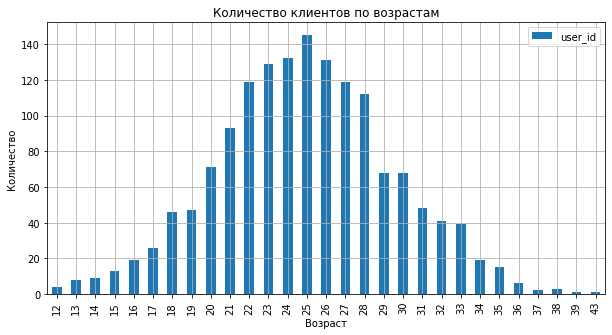

In [24]:
#возраст клиентов
(
    users_go.pivot_table(index='age', values='user_id', aggfunc='count').sort_values(by='age', ascending=True)
    .plot(kind='bar' , grid=True, figsize=(10, 5))
)
plt.title('Количество клиентов по возрастам')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

In [25]:
print('Среднее значение возраста клиентов', users_go['age'].mean().round(1))
users_go['age'].describe()

Среднее значение возраста клиентов 24.9


count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

*Средний возраст клиентов нормально распределены с медианой примерно в 25 лет, при этом средний возраст и медиана почти равны.*

In [26]:
#расстояние, которое клиент преодолел за одну поездку
rides_go['distance'].describe()

count    18068.000000
mean      3070.659992
std       1116.831222
min          0.860000
25%       2543.227500
50%       3133.610000
75%       3776.220000
max       7211.010000
Name: distance, dtype: float64

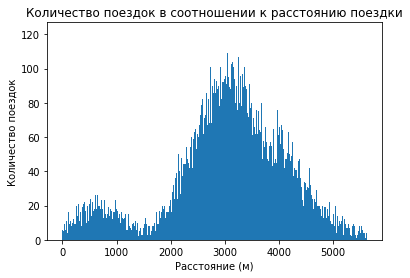

In [27]:
plt.hist(rides_go['distance'], bins=500, range=(1,5620))
plt.title('Количество поездок в соотношении к расстоянию поездки')
plt.xlabel('Расстояние (м)')
plt.ylabel('Количество поездок')
plt.show()

*За одну поездку клиенты преодолевают от 1 до ~6000 м. Медиана всех значений равна где то 3000-3100 м. Выбросов нет.
Есть небольшой всплеск слева, эта аномалия возможно, связанна с тем, что некоторые поездки были до 1500м. Таких поездок было не слишком много. Клиенты могут взять самокат, чтобы например доехать до магазина/работы/друга на соседней улице условно. Я думаю, что эти данные не являются выбросами.*

In [28]:
#продолжительность поездок
rides_go['duration'].describe()

count    18068.000000
mean        18.303520
std          6.094928
min          1.000000
25%         14.000000
50%         18.000000
75%         22.000000
max         41.000000
Name: duration, dtype: float64

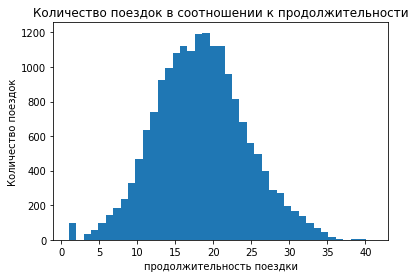

In [29]:
plt.hist(rides_go['duration'], bins=41, range=(1,41))
plt.title('Количество поездок в соотношении к продолжительности')
plt.xlabel('продолжительность поездки')
plt.ylabel('Количество поездок')
plt.show()

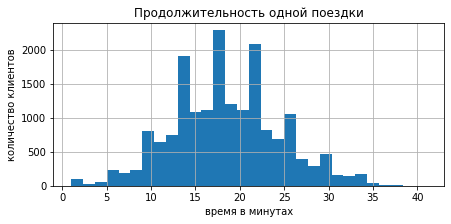

count    18068.000000
mean        18.303520
std          6.094928
min          1.000000
25%         14.000000
50%         18.000000
75%         22.000000
max         41.000000
Name: duration, dtype: float64

In [30]:
rides_go['duration'].plot(kind = 'hist', grid=True, figsize = (7,3), bins = 30)
plt.title('Продолжительность одной поездки')
plt.xlabel('время в минутах')
plt.ylabel('количество клиентов')
plt.show()
rides_go['duration'].describe()

*~ Средняя продолжительность поездки 18 минут.*

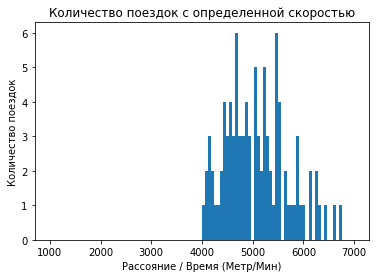

In [31]:
plt.hist(rides_go['distance'] / rides_go['duration'], bins=100, range=(1000,7000))
plt.title('Количество поездок с определенной скоростью')
plt.xlabel('Рассояние / Время (Метр/Мин)')
plt.ylabel('Количество поездок')
plt.show()

In [32]:
print('Максимальная скорость перемещения (метр/мин)', (rides_go['distance'] / rides_go['duration']).max())

Максимальная скорость перемещения (метр/мин) 7211.01


Есть аномалия - время поездок с временем менее 1 минуты. В столбце времени присутствуют аномалии. Средняя скорость самокатов варьируется от 4000 до 7211,01 метр/мин, но это практически не возможно. О таком лушче всего сообщить рукводителям проката. Пока что ничего со значениями делать не будем, оставим как есть.

# Вывод:

* Услугами сервиса аренды самокатов пользуются больше всего в южных городах, где сезон проката длительнее, но интересно, что на втором месте оказался Екатеринбург, находящийся на Урале, нде не так тепло.

* Количество клиентов без подписки free 54,4% превышает количество клиентов с подпиской ultra 45,6%.

* Средний возраст клиентов нормально распределены с медианой примерно в 25 лет, при этом средний возраст и медиана практически совпадают.

* За одну поездку клиенты преодолевают от 1 до ~6000 м. Медиана всех значений равна где то 3000-3100 м.

* Средняя продолжительность поездки 18 минут

* Есть аномалия - время поездок с временем менее 1 минуты. В столбце времени присутствуют аномалии. Средняя скорость самокатов варьируется от 4000 до 7211,01 метр/мин, но это практически не возможно. О таком лушче всего сообщить рукводителям проката. Пока что ничего со значениями делать не будем, оставим как есть.

#### Шаг 4. Объединение данных

In [33]:
#объединение данных о пользователях, поездках и подписках в один датафрейм
data = pd.merge(users_go, subscriptions_go, on='subscription_type')
data = pd.merge(rides_go, data, on='user_id')

In [34]:
#размеры датасетов до объединения
users_go.shape[0]

1534

In [35]:
rides_go.shape[0]

18068

In [36]:
subscriptions_go.shape[0]

2

In [37]:
# размер нового Data
data.shape[0]

18068

In [38]:
# Проверим на пропущенные значения
data.isna().sum() 

user_id              0
distance             0
duration             0
date                 0
month                0
year                 0
name                 0
age                  0
city                 0
subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [39]:
print('Количество явных дубликатов в `data` = ', data.duplicated().sum(), '\n')
data.info()

Количество явных дубликатов в `data` =  0 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   distance           18068 non-null  float64       
 2   duration           18068 non-null  int64         
 3   date               18068 non-null  datetime64[ns]
 4   month              18068 non-null  int64         
 5   year               18068 non-null  int64         
 6   name               18068 non-null  object        
 7   age                18068 non-null  int64         
 8   city               18068 non-null  object        
 9   subscription_type  18068 non-null  object        
 10  minute_price       18068 non-null  int64         
 11  start_ride_price   18068 non-null  int64         
 12  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns]

In [40]:
data.head()

,user_id,distance,duration,date,month,year,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.92,26,2021-01-01,1,2021,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.59,16,2021-01-18,1,2021,Кира,22,Тюмень,ultra,6,0,199
2,1,754.16,7,2021-04-20,4,2021,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.78,19,2021-08-11,8,2021,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.69,27,2021-08-28,8,2021,Кира,22,Тюмень,ultra,6,0,199


*Датафрейм data объединяющий таблицы rides_go, users_go, subscriptions_go  имеет 18068 строк во всех столбцах, что соответствует исходной таблице rides_go и указывает на отсутствие пропусков в столбцах. Проведена проверка на явные дубликаты.*

In [41]:
#датафрейм о клиентах без подписки
data_free = data[data['subscription_type'] == 'free']
data_free.head()

,user_id,distance,duration,date,month,year,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
6500,700,2515.69,15,2021-01-02,1,2021,Айдар,22,Омск,free,8,50,0
6501,700,846.93,17,2021-02-01,2,2021,Айдар,22,Омск,free,8,50,0
6502,700,4004.43,21,2021-02-04,2,2021,Айдар,22,Омск,free,8,50,0
6503,700,1205.91,10,2021-02-10,2,2021,Айдар,22,Омск,free,8,50,0
6504,700,3047.38,18,2021-02-14,2,2021,Айдар,22,Омск,free,8,50,0


In [42]:
#датафрейм о клиентах с подспикой
data_ultra = data[data['subscription_type'] == 'ultra']
data_ultra.head()

,user_id,distance,duration,date,month,year,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.92,26,2021-01-01,1,2021,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.59,16,2021-01-18,1,2021,Кира,22,Тюмень,ultra,6,0,199
2,1,754.16,7,2021-04-20,4,2021,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.78,19,2021-08-11,8,2021,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.69,27,2021-08-28,8,2021,Кира,22,Тюмень,ultra,6,0,199


In [43]:
#проверим разделение
if len(data) == (len(data_free) + len(data_ultra)):
    print('Разделение прошло успешно')
else:
    print('ვაიმე!')

Разделение прошло успешно


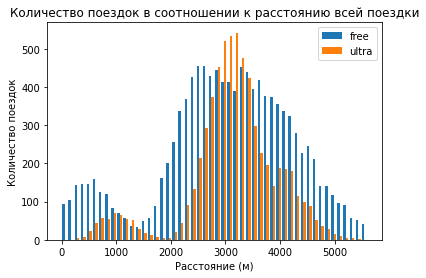

In [44]:
#визуализируем информацию о расстоянии и времени поездок для пользователей обеих категорий
plt.hist([data_free['distance'], data_ultra['distance']], bins=50, range=(1,5600), label=['free', 'ultra'])
plt.legend(loc='upper right')
plt.title('Количество поездок в соотношении к расстоянию всей поездки')
plt.xlabel('Расстояние (м)')
plt.ylabel('Количество поездок')
plt.show()

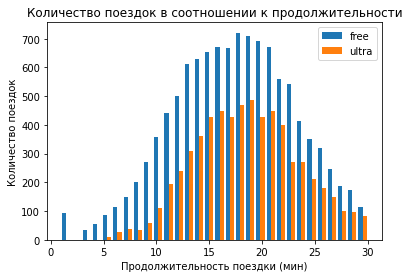

In [45]:
plt.hist([data_free['duration'], data_ultra['duration']], bins=30, range=(1,30), label=['free', 'ultra'])
plt.legend(loc='upper right')
plt.title('Количество поездок в соотношении к продолжительности')
plt.xlabel('Продолжительность поездки (мин)')
plt.ylabel('Количество поездок')
plt.show()

In [46]:
data_free['distance'].describe()

count    11568.000000
mean      3045.495284
std       1246.173810
min          0.860000
25%       2366.560000
50%       3114.650000
75%       3905.695000
max       7211.010000
Name: distance, dtype: float64

In [47]:
data_ultra['distance'].describe()

count    6500.000000
mean     3115.445431
std       836.895369
min       244.210000
25%      2785.447500
50%      3148.640000
75%      3560.577500
max      5699.770000
Name: distance, dtype: float64

In [48]:
data_free['duration'].describe()

count    11568.000000
mean        17.890992
std          6.330250
min          1.000000
25%         13.000000
50%         18.000000
75%         22.000000
max         35.000000
Name: duration, dtype: float64

In [49]:
data_ultra['duration'].describe()

count    6500.000000
mean       19.037692
std         5.577439
min         4.000000
25%        15.000000
50%        19.000000
75%        22.000000
max        41.000000
Name: duration, dtype: float64

* *Для пользователей без подписки:*
среднее растояние равно 3045 м
в основном поездки находятся в диапозоне от 2366 до 3906 м
большее количество коротких поездок 400-500 м
* *Для пользователей с подпиской:*
среднее расстояние равно 3115 м
в основном поездки находятся в диапозоне от 2785 до 3560 м

* Больший диапозон у клиентов без подписки. Поездки короче 500 м чаще встречаются у клиентов без подписки.

* По длительности у клиента с подпиской поездки длительнее. С подпиской от 5 минут до 30 мин, а без подписки от 2 до 28 мин. Разброс явно шире у клиентов без подписки.

* Количество поездок у клиентов без подписки выше около 740 (пик), а у клиентов с подпиской 500.

* Медиана более стабильное значение. Медиана не реагирует на очень высокие или наоборот слишком низкие показатели в данных. Медиана и среднее значение минимально отличаются вне зависимости от наличия или отсутствия подписки, те распределение почти идеально симметрично.

# Вывод:



* **Для пользователей без подписки:**
среднее растояние равно 3045 м
в основном поездки находятся в диапозоне от 2366 до 3906 м
большее количество коротких поездок 400-500 м
* **Для пользователей с подпиской:**
среднее расстояние равно 3115 м
в основном поездки находятся в диапозоне от 2785 до 3560 м

* Больший диапозон у клиентов без подписки. Поездки короче 500 м чаще встречаются у клиентов без подписки.

* По длительности у клиента с подпиской поездки длительнее. С подпиской от 5 минут до 30 мин, а без подписки от 2 до 28 мин. Разброс явно шире у клиентов без подписки.

* Количество поездок у клиентов без подписки выше около 740 (пик), а у клиентов с подпиской 500.

#### Шаг 5. Подсчёт выручки

In [50]:
users_months_revenue = data.pivot_table(
    index=('user_id', 'month'), 
    values=(
        'distance', 
        'duration', 
        'minute_price', 
        'start_ride_price', 
        'subscription_fee'
    ), 
    aggfunc=({'distance':{'count', 'sum'}, 
             'duration':'sum',
             'minute_price': 'mean',
             'start_ride_price':'mean',
             'subscription_fee':'mean',})
)

users_months_revenue.columns = [
    'count', 'distance', 
    'duration', 
    'minute_price',
    'start_ride_price', 
    'subscription_fee'
]


users_months_revenue.head()

count  distance  duration  minute_price  start_ride_price  \
user_id month                                                              
1       1          2   7027.51        42             6                 0   
        4          1    754.16         7             6                 0   
        8          2   6723.47        46             6                 0   
        10         2   5809.91        32             6                 0   
        11         3   7003.50        56             6                 0   

               subscription_fee  
user_id month                    
1       1                   199  
        4                   199  
        8                   199  
        10                  199  
        11                  199

In [51]:
users_months_revenue['revenue'] = (
users_months_revenue['start_ride_price']*users_months_revenue['count']+
users_months_revenue['minute_price']*users_months_revenue['duration']+
users_months_revenue['subscription_fee'])

print('Записи с ', data['date'].min(), 'по', data['date'].max())
print ('Выручка за 2021 год составила :',users_months_revenue['revenue'].sum(), 'руб.')

Записи с  2021-01-01 00:00:00 по 2021-12-30 00:00:00
Выручка за 2021 год составила : 3878641 руб.


In [52]:
users_months_revenue['revenue']

user_id  month
1        1        451
         4        241
         8        475
         10       391
         11       535
                 ... 
1534     6        308
         8        484
         9        234
         11       824
         12       178
Name: revenue, Length: 11331, dtype: int64

*Выручка сервиса аренды самокатов "GoFast" за год  3 878 641.0 руб.*

#### Шаг 6. Проверка гипотез

*6.1 Тратят ли пользователи с подпиской больше времени на поездки?*

Выдвинем гипотезы.

Нулевая H0 и альтернативная Н1 гипотезы:

* Гипотеза Н0: Средняя продолжительность поездок с подпиской ultra и без free равна
* Гипотеза Н1: Средняя продолжительность поездок с подпиской ultra больше продолжительности поездок без подписок free

In [53]:
results = st.ttest_ind(
    data_ultra['duration'], 
    data_free['duration'], 
 
    alternative='greater')
print(results.pvalue)

alpha = 0.05
if results.pvalue < alpha:
    print('Отвергаем гипотезу')
else:
    print('Не получилось отвергнуть гипотезу')

2.4959453720736625e-34
Отвергаем гипотезу


*Нулевую гипотезу отвергаем, есть основания считать, что средняя продолжительность поездки с подпиской больше продолжительности поездок без подписки.*

*6.2 Оптимальное растояние поездки с точки зрения износа самоката для пользователей с подпиской*

Выдвинем гипотезы.

* Н0: Среднее расстояние поездок с подпиской ultra равно оптимальному расстоянию в 3130 метров.
* Н1: Среднее расстояние поездок с подпиской ultra больше оптимального в 3130 метров.

In [54]:
distance = 3130
alpha = 0.05

results = st.ttest_1samp(
    data_ultra['distance'], 
    distance,
    alternative='greater')

print(results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем гипотезу')
else:
    print('Не получилось отвергнуть гипотезу')

0.9195362605842414
Не получилось отвергнуть гипотезу


*Не получилось отвергнуть гипотезу о том, что среднее расстояние поездок с использованием подписки 'ultra' (меньше или) равно 3130 метров*

6.3 Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

Выдвинем гипотезы:

Н0: Помесячная средняя выручка от пользователей с подпиской равна помесячной средней выручке от пользователей без подписки.
Н1: Помесячная средняя выручка от пользователей с подпиской больше помесячной средней выручки от пользователей без подписки.

In [55]:
results = st.ttest_ind(
    users_months_revenue.loc[users_months_revenue['subscription_fee'] > 0, 'revenue'], 
    users_months_revenue.loc[users_months_revenue['subscription_fee'] == 0, 'revenue'], 
    equal_var=True, 
    alternative='greater')
print(results.pvalue)

alpha = 0.05
if results.pvalue < alpha:
    print('Отвергаем гипотезу')
else:
    print('Не получилось отвергнуть гипотезу')

1.8850394384715216e-31
Отвергаем гипотезу


*Нулевая гипотеза отвергнута, есть основания полагать, что помесячная средняя выручка от пользователей с подпиской ultra, выше помесячной средней выручки от пользователей без подписки free*

6.4 Ситуация: не получилось отвергнуть нулевую гипотезу о том, что средняя выручка от поездок с использованием подписки 'ultra' (больше или) равна средней выручке с ипользованием подписки 'free'.Значит, как минимум, выручка от подписки 'ultra' не меньше, чем от плитки 'free', и её следует развивать.

* Выборки в этом случае будут зависимыми, иначе — парными. Парная выборка означает, что некоторая переменная измеряется дважды для одних и тех же объектов. Если в данных некоторая переменная измеряется дважды (количество обращений до обновления и после него) для одних и тех же объектов (клиент) и имеют одинаковые размеры, тогда можно применить метод st.ttest_rel(), гипотеза здесь будет односторонняя, потому что она предполагает утверждение «больше» или «меньше».

_**Вывод:**_

* Нулевую гипотезу отвергаем, есть основания полагать, что средняя продолжительность поездки с подпиской больше продолжительности поездок без подписки

* Не получилось отвергнуть гипотезу о том, что среднее расстояние поездок с использованием подписки 'ultra' (меньше или) равно 3130 метров

* Нулевая гипотеза отвергнута, есть основания полагать, что помесячная средняя выручка от пользователей с подпиской ultra, выше помесячной средней выручки от пользователей без подписки free

* Выборки в этом случае будут зависимыми, иначе — парными. Парная выборка означает, что некоторая переменная измеряется дважды для одних и тех же объектов. Если в данных некоторая переменная измеряется дважды (количество обращений до обновления и после него) для одних и тех же объектов (клиент) и имеют одинаковые размеры, тогда можно применить метод st.ttest_rel()

#### Шаг 7. Распределения

7.1 Какое количество промокодов нужно раздать на один бесплатный месяц, чтобы в следующем месяце как минимум 100 существующих клиентов продлили подписку

При раздаче промокодов в количестве 1161 вероятность, не выполнить план меньше 5.0 %


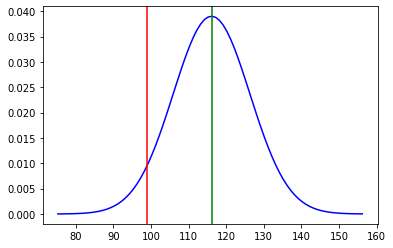

In [56]:
n = 1000
p = 0.1
k = 99
binom_cdf = 0.05

while binom_cdf < binom.cdf(k, n, p):
    n += 1
print(f'При раздаче промокодов в количестве {n} вероятность, не выполнить план меньше {binom.cdf(k, n, p).round(2)*100} %')

# зададим мат.ожидание и ст.отклонение нормального распределения равными
# мат.ожиданию и ст.отклонению биномиального распределения
mu = n * p
sigma = (n * p * (1 - p))**0.5

arange = np.arange((mu - 4 * sigma),(mu + 4 * sigma),1)

plt.plot(arange, st.norm.pdf(arange, mu, sigma), 'b-')
plt.axvline(x=k, color='red')
plt.axvline(x=mu, color='green')
plt.show()

*Необходимо раздать минимум 1161 промокода, тогда возможно, что около 100 существующих клиентов продлят подписку (продлевают подписку 10% пролучивших промокод) не выполнить план меньше 5.0 %*

7.2 Оценить вероятность того, что уведомление откроют не более 399,5 тыс. пользователей, если разослать 1 млн уведомлений

Вероятность открытия сообщений: 0.15371708296369768


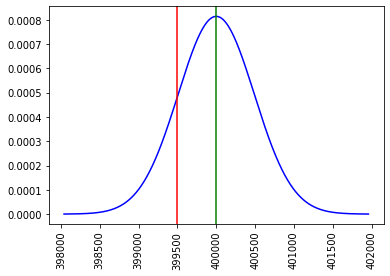

In [57]:
#параметры биномиального распределения
n = 1000000
p = 0.4
k = 399500
#зададим мат.ожидание и ст.отклонение нормального распределения равными
#мат.ожиданию и ст.отклонению биномиального распределения
mu = n * p
sigma = (n * p * (1 - p))**0.5

#задаём нормальное распределение
distr = st.norm(mu, sigma) 

#считаем вероятность хвоста слева от 399.5 тысяч
result = distr.cdf(k)
print('Вероятность открытия сообщений:', result)

arange = np.arange((mu - 4 * sigma),(mu + 4 * sigma),1)
plt.plot(arange, st.norm.pdf(arange, mu, sigma), 'b-')
plt.xticks(rotation=90)
plt.axvline(x=k, color='red')
plt.axvline(x=mu, color='green')
plt.show()

При условии, что мы разошлем 1 млн уведомлений (откроют только 40 % получивших клиентов), тогда вероятность того, что уведомление откроют не более 399,5 тыс. пользователей составит 0.1537 или 15,37 %.

# Общий вывод:


В процессе исследования данных о пользователях популярного сервиса аренды самокатов 'GoFast', были выполнены следующие этапы и сделаны выводы:

* Загрузка данных
users_go 1565 записи, пропуски отсутствуют, количество явных дубликатов 31. users_go 18068 записи, пропуски отсутствуют, явных дубликатов нет. В ‘rides_go’ обнаружено 4 столбца и 18068 строк без пропусков и выбросов. Возможно наличие выбросов в столбцах ‘distance’ и ‘duration’. Тип данных в столбце ‘subscription_type’ необходимо изменить.

* Предобработка данных
В данных users_go округлили distance в метрах до 2 знаков после запятой; Округлили duration перевели в int; Привели столбец date к типу datetime64; Создали столбец month с номером месяца из date; В данных subscriptions_go изменений не проводили.

* Исследовательский анализ данных
Услугами сервиса аренды самокатов пользуются больше всего в южных городах, где сезон проката длительнее, но интересно, что на втором месте оказался Екатеринбург, находящийся в уральском округе, нде не так тепло соответственно.

* Количество клиентов без подписки free 54,4% превышает количество клиентов с подпиской ultra 45,6%.

* Средний возраст клиентов нормально распределены с медианой примерно в 25 лет, при этом средний возраст и медиана практически совпадают.

* За одну поездку клиенты преодолевают от 1 до ~6000 м. Медиана всех значений равна где то 3000-3100 м. Выбросов не замечено.

* Медиана поездок находится на ~18 мин. Обнаружено аномальное время поездок (около 100 шт) с временем менее 1 минуты. Построенные гисторгаммы указывают, что в столбце времени присутствуют аномалии.

**Объединение данных**
* Для пользователей без подписки:

среднее растояние равно 3045 м в основном поездки находятся в диапозоне от 2366 до 3906 м большее количество коротких поездок 400-500 м

* Для пользователей с подпиской:

среднее расстояние равно 3115 м в основном поездки находятся в диапозоне от 2785 до 3560 м

* У клиентов без подписки диапозон по расстоянию больше.

* По длительности у клиента с подпиской поездки длительнее. С подпиской от 5 минут до 30 мин, а без подписки от 2 до 28 мин.

* Количество поездок у клиентов без подписки выше около 740 (пик), а у клиентов с подпиской 500.

**Подсчёт выручки**
Выручка сервиса аренды самокатов "GoFast" за год составила 3 878 641.0.0 руб.

**Проверка гипотез**

* Можно утверждать, что средняя длительность поездки с подпиской 'ultra' больше длительности поездок без подписки 'free'

* Не получилось отвергнуть гипотезу о том, что среднее расстояние поездок с использованием подписки 'ultra' (меньше или) равно 3130 метров

* Гипотеза отвергнута, тк выручка от подписки 'ultra' не меньше, чем от клиентов без подписки 'free'

* Выборки в этом случае будут зависимыми, иначе — парными. Парная выборка означает, что некоторая переменная измеряется дважды для одних и тех же объектов. Если в данных некоторая переменная измеряется дважды (количество обращений до обновления и после него) для одних и тех же объектов (клиент) и имеют одинаковые размеры, тогда можно применить метод scipy.stats.ttest_rel()

_**Итог всего исследования:** клиенты с подпиской являются более выгодными для сервиса. Руководству сервиса стоит приложить усилия для перехода клиентов на подписку._